In [110]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [128]:
d = 0.46 # мм
d_d = 0.01 # мм

l = 178 # см
d_l = 1 # см

h = 137 # см
d_h = 2 # см

r = 15 # мм
d_r = 0.1 # мм

d_m = 0.1 # г

n_0 = 261 # мм
delta_n = 1 # мм

# Предельная нагрузка

In [129]:
sigma_lim = 900 # Н/мм^2
S = np.pi * d * d / 4
P_max = 0.3 * sigma_lim * S

eps_S = 2 * d_d / d # = eps_Pmax
d_P_max = eps_S * P_max

print(f"P_max = {P_max:.2f} +- {d_P_max:.2f}")

g = 9.81
d_g = 0.01

m_max = 2468.4 # г
d_m_max = 0.9 # г
P_m_max = m_max / 1000 * g
d_P_m_max = (d_m_max / m_max + d_g / g) * P_m_max

print(f"P_m_max = {P_m_max:.2f} +- {d_P_m_max:.2f}")

P_max = 44.87 +- 1.95
P_m_max = 24.22 +- 0.03


# Обработка данных

In [130]:
data = pd.read_csv(
    "data/data1311.csv",
    sep=r";",      # разделитель — пробелы/табы
    decimal=",",     # запятая как десятичный разделитель
    skiprows=[1],    # пропустить строку с единицами "мм мм"
    encoding="utf-8"
)

In [131]:
data["d_m"] = data["N"] * d_m # учитываем погрешность суммы грузов
data["d_n"] = data["n_1"] - n_0
data["d_l"] = data["d_n"] * r / (2 * h * 10) # мм
data["eps_d_l"] = delta_n / data["d_n"] + d_r / r + d_h / h
data.iloc[13, 6] = 0.1
data["d_d_l"] = data["eps_d_l"] * abs(data["d_l"])
data["P"] = (data["m"] / 1000) * g # Н
data["eps_P"] = data["d_m"] / data["m"] + d_g / g
data["d_P"] = data["P"] * data["eps_P"]
data["eps_k"] = data["eps_P"] + data["eps_d_l"]

data
#data[["d_l", "d_d_l", "P", "d_P"]]

,n_1,m,N,d_m,d_n,d_l,eps_d_l,d_d_l,P,eps_P,d_P,eps_k
0,293,504.4,1,0.1,32,0.175182,0.052515,0.009200,4.948164,0.001218,0.006025,0.053733
1,322,749.9,2,0.2,61,0.333942,0.037659,0.012576,7.356519,0.001286,0.009461,0.038945
2,348,995.5,3,0.3,87,0.476277,0.032759,0.015603,9.765855,0.001321,0.012898,0.034080
3,375,1241.1,4,0.4,114,0.624088,0.030037,0.018746,12.175191,0.001342,0.016335,0.031379
4,397,1486.7,5,0.5,136,0.744526,0.028618,0.021307,14.584527,0.001356,0.019772,0.029974
5,425,1732.0,6,0.6,164,0.897810,0.027363,0.024567,16.990920,0.001366,0.023206,0.028729
6,449,1977.3,7,0.7,188,1.029197,0.026584,0.027361,19.397313,0.001373,0.026640,0.027958
7,474,2222.8,8,0.8,213,1.166058,0.025960,0.030271,21.805668,0.001379,0.030076,0.027339
8,499,2468.4,9,0.9,238,1.302920,0.025467,0.033181,24.215004,0.001384,0.033513,0.026851
9,475,2222.9,8,0.8,214,1.171533,0.025938,0.030387,21.806649,0.001379,0.030077,0.027317


In [132]:
def least_squares(x, y): # y = kx
    coeff = np.mean(x*y) / np.mean(x*x)
    err = 1 / np.sqrt(len(x) - 1) * np.sqrt((y*y).mean() / (x*x).mean() - coeff ** 2)
    return coeff, err # coeff = k

def least_squares_line(x, y): # y = kx + b
    k = (np.mean(x*y) - np.mean(x) * np.mean(y)) / (np.mean(x*x) - (np.mean(x) ** 2))
    d_k = 1 / np.sqrt(len(x) - 1) * np.sqrt(((y*y).mean() - (y.mean() ** 2)) / ((x*x).mean() - (x.mean() ** 2)) - k ** 2)
    b = np.mean(y) - k * np.mean(x)
    d_b = d_k * np.sqrt(np.mean(x*x) - (np.mean(x) ** 2))
    return k, d_k, b, d_b

k, d_k_stat, b, d_b = least_squares_line(data["d_l"], data["P"]) # Н/мм
print(k, d_k_stat, b, d_b)

16.969908041610438 0.15825329510152428 1.861120486581239 0.06109608483661916


In [137]:
d_k_inst = data["eps_k"].mean() * k
d_k = np.sqrt(d_k_stat ** 2 + d_k_inst ** 2)
print(k, d_k, d_k_stat, d_k_inst)

16.969908041610438 0.6578511989676874 0.15825329510152428 0.6385327670313667


$E = \frac{4kl}{\pi d^2}$

In [143]:
E = 4 * k * l / (np.pi * d * d) / 100 * 1000 * 1000 * 1000 / 1000 / 1000 / 1000 # ГПа
eps_E = d_k / k + d_l / l + 2 * d_d / d
d_E = eps_E * E
# Н * см / (мм^3)
print(E, d_E)

181.75817212000857 15.969634263290603


# Построение графика

In [134]:
xline = np.linspace(0, 2, 10)

In [135]:
y = xline * k + b

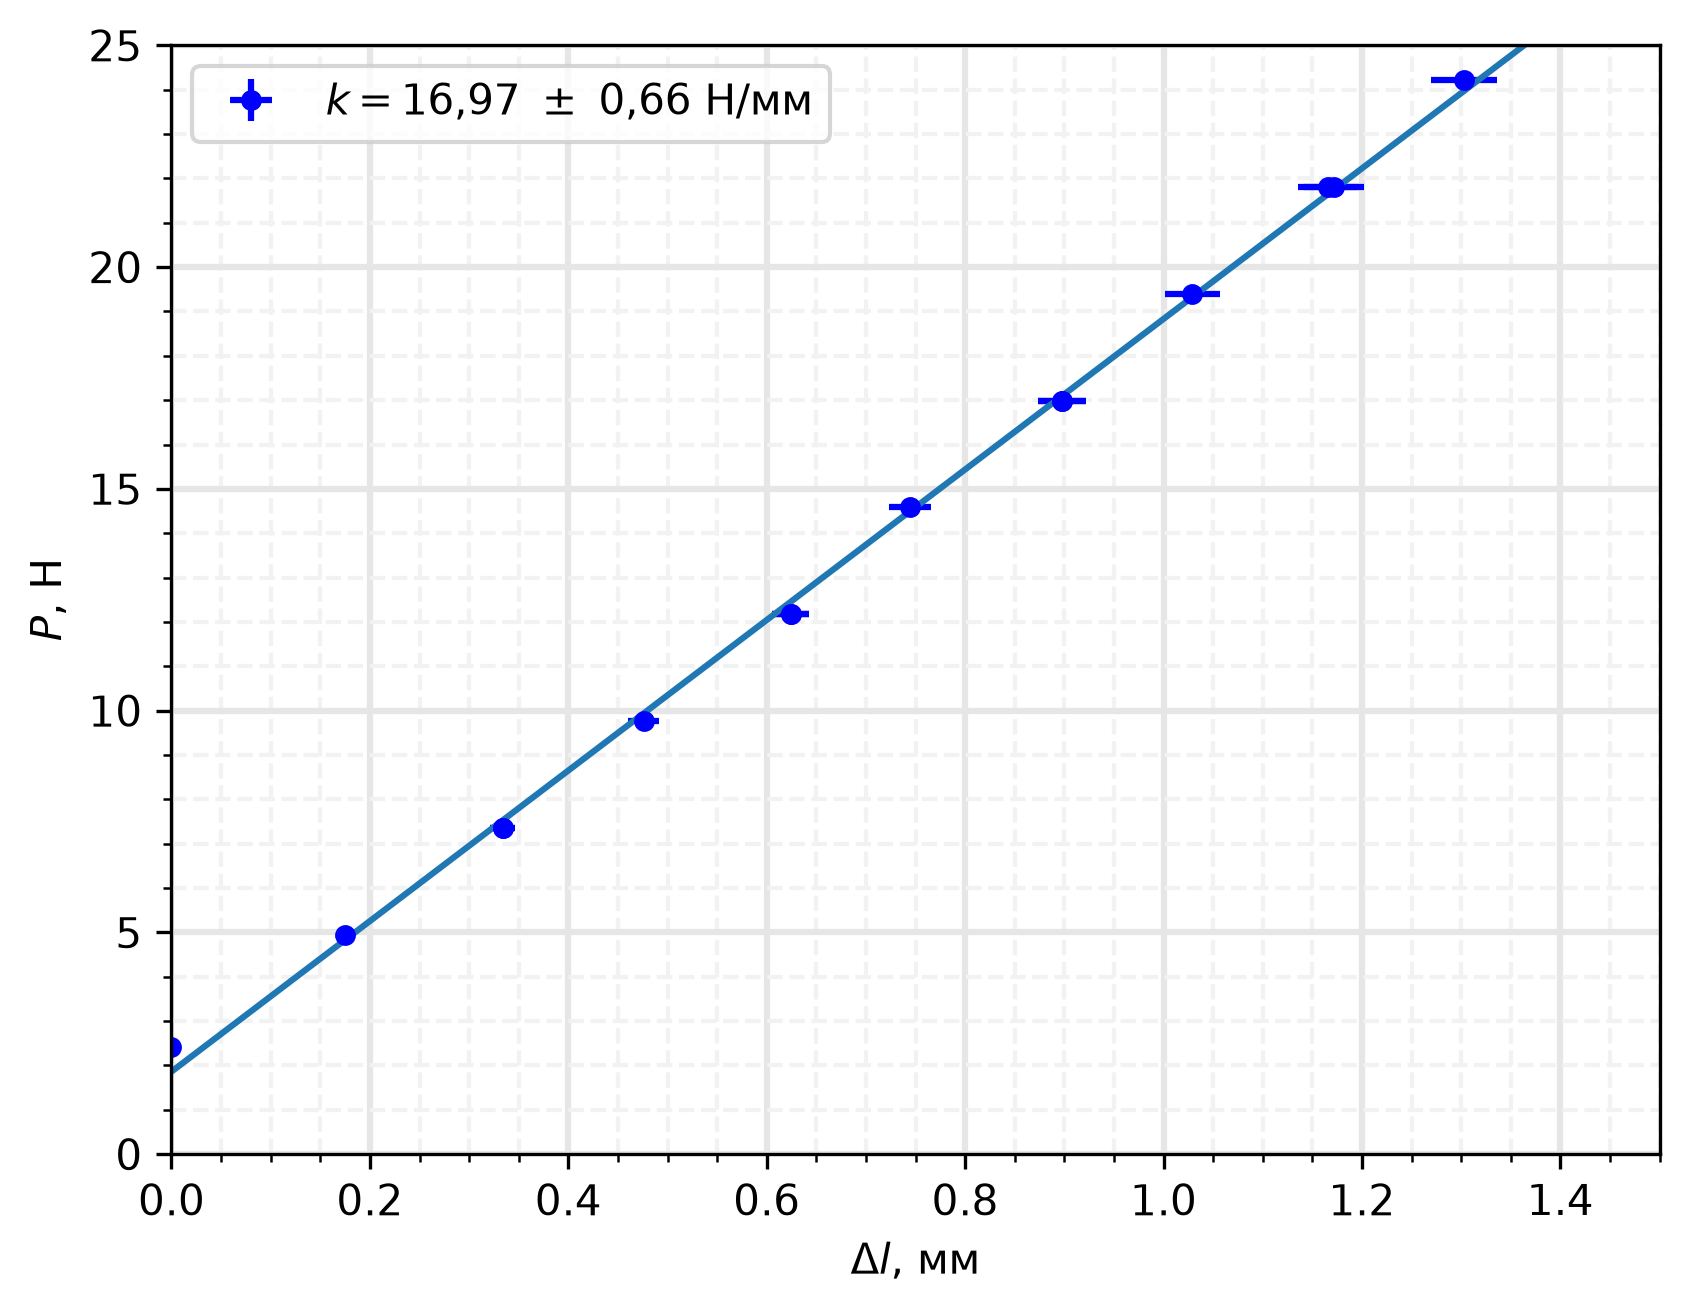

In [138]:
plt.figure(dpi=300)
plt.axis([0, 1.5, 0, 25])
plt.minorticks_on()
plt.ylabel("$P$, Н")
plt.xlabel("$\\Delta l$, мм")

plt.grid(visible=True, which='major', linestyle='-', linewidth=1.5, color='0.9') # Формат основных линиий сетки
plt.grid(visible=True, which='minor', linestyle='--', linewidth=1, color='0.95') # Формат побочных линий, цвет указывается как оттенок серого - 0.0 - чёрный, 1.0 - белый

plt.errorbar(data["d_l"], data["P"], xerr=data["d_d_l"], yerr=data["d_P"], fmt="bo", markersize=4, label="$k=16{,}97\\ \\pm\\ 0{,}66$ Н/мм")
plt.plot(xline, y, color="tab:blue")

plt.legend()
plt.savefig("images/graph1311.pdf", format="pdf")